In [1]:
# Import or install Sionna
try:
    import sionna.rt
except ImportError as e:
    import os
    os.system("pip install sionna-rt")
    import sionna.rt

# Other imports
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

no_preview = True  # Disable the interactive preview widget.

# Import relevant components from Sionna RT
from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, Camera,\
                      PathSolver, RadioMapSolver, subcarrier_frequencies

from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, RadioMaterial, Camera
from sionna.rt.utils import r_hat

In [ ]:
import importlib
import sys

def check_tensorflow():
    if importlib.util.find_spec("tensorflow") is None:
        print("[TensorFlow]  not installed")
        return
    import tensorflow as tf
    print(f"[TensorFlow] version: {tf.__version__}")
    print(f"[TensorFlow] CUDA support: {tf.test.is_built_with_cuda()}")
    print(f"[TensorFlow] available GPUs: {tf.config.list_physical_devices('GPU')}")

def check_pytorch():
    if importlib.util.find_spec("torch") is None:
        print("\n[PyTorch]  not installed")
        return
    import torch
    print(f"\n[PyTorch] version: {torch.__version__}")
    print(f"[PyTorch] CUDA available: {torch.cuda.is_available()}")
    if torch.cuda.is_available():
        print(f"[PyTorch] GPU count: {torch.cuda.device_count()}")
        for i in range(torch.cuda.device_count()):
            print(f"[PyTorch] GPU {i} name: {torch.cuda.get_device_name(i)}")

def check_sionna():
    if importlib.util.find_spec("sionna") is None:
        print("\n[Sionna]  not installed")
        return
    import sionna
    print(f"\n[Sionna] version: {sionna.__version__}")
    try:
        # Check whether Sionna can access TensorFlow GPUs.
        import tensorflow as tf
        gpus = tf.config.list_physical_devices('GPU')
        if gpus:
            print(f"[Sionna] available GPU count: {len(gpus)}")
        else:
            print("[Sionna] no GPU detected through TensorFlow")
    except Exception as e:
        print(f"[Sionna] GPU check failed: {e}")

if __name__ == "__main__":
    print(f"Python version: {sys.version}\n")
    check_tensorflow()
    check_pytorch()
    check_sionna()


Python version: 3.12.3 (main, Mar 23 2026, 19:04:32) [GCC 13.3.0]



2026-07-09 03:03:48.021351: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-09 03:03:48.052711: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1783591428.066573  246795 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1783591428.070254  246795 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1783591428.080469  246795 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

[TensorFlow] version: 2.19.0
[TensorFlow] CUDA support: True
[TensorFlow] available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

[PyTorch] version: 2.5.1+cu121
[PyTorch] CUDA available: True
[PyTorch] GPU count: 1
[PyTorch] GPU 0 name: NVIDIA GeForce RTX 3060 Ti

[Sionna] version: 1.1.0
[Sionna] available GPU count: 1


In [3]:
import tensorflow as tf
print("GPU devices:", tf.config.list_physical_devices('GPU'))

GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
import os
gpu_num = 0 # Use "" to use the CPU
os.environ["CUDA_VISIBLE_DEVICES"] = f"{gpu_num}"
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import shapely
from utils import *
from pyproj import Transformer

import os
import json
import time
import numpy as np
import matplotlib.pyplot as plt
import mitsuba as mi
import csv

In [5]:
# Load integrated scene
# sionna.rt.scene.munich
from pathlib import Path

def find_project_root(start=None):
    current = Path.cwd() if start is None else Path(start).resolve()
    for candidate in (current, *current.parents):
        if (candidate / "assets" / "raytrack_scene" / "scene.xml").is_file():
            return candidate
    raise FileNotFoundError("Could not locate the RayLoc project root.")

PROJECT_ROOT = find_project_root()
GENERATED_DIR = PROJECT_ROOT / "generated"
GENERATED_DIR.mkdir(parents=True, exist_ok=True)
SCENE_PATH = PROJECT_ROOT / "assets" / "raytrack_scene" / "scene.xml"

scene = load_scene(str(SCENE_PATH))
# scene.preview()

2026-07-09 03:05:36 WARN wrk6 [HDRFilm] Monochrome mode enabled, setting film output pixel format to 'luminance' (was rgb).

In [6]:
#convert lat lon to coordinate
def sionna_coord(target_latlon):

    #bound
    bl = (-122.312299126737, 47.65074792715546)
    ur = (-122.30187970485449, 47.65690207846001)
    box = [bl, (bl[0], ur[1]), ur, (ur[0], bl[1])]

    target_coord_flipped = (target_latlon[1], target_latlon[0])

    #find epsg code for projection
    EPSG_code = get_utm_epsg_code_from_gps(bl[0], bl[1])
    to_utm = Transformer.from_crs("EPSG:4326", EPSG_code, always_xy=True)

    target_utm = to_utm.transform(target_coord_flipped[0], target_coord_flipped[1])

    #find center
    ground_utm = [to_utm.transform(lon, lat) for lon, lat in box]
    ground_polygon_utm = shapely.geometry.Polygon(ground_utm)
    ground_envelop = ground_polygon_utm.envelope
    center_x = ground_envelop.centroid.x
    center_y = ground_envelop.centroid.y

    #relative coord
    relative_coord = (target_utm[0] - center_x, target_utm[1] - center_y)

    return relative_coord

def sionna_coord_batch(latlon_array):
    """
    latlon_array: [N,2] -> [[lat, lon], ...]
    return: [N,2] -> [[x, y], ...]
    """

    latlon_array = np.asarray(latlon_array)
    assert latlon_array.shape[1] == 2, "Input must be Nx2 [lat, lon]"

    # =========================
    # 1. bounding box
    # =========================
    bl = (-122.312299126737, 47.65074792715546)
    ur = (-122.30187970485449, 47.65690207846001)
    box = [bl, (bl[0], ur[1]), ur, (ur[0], bl[1])]

    # =========================
    # 2. projection (computed once)
    # =========================
    EPSG_code = get_utm_epsg_code_from_gps(bl[0], bl[1])
    to_utm = Transformer.from_crs("EPSG:4326", EPSG_code, always_xy=True)

    # =========================
    # 3. compute center
    # =========================
    ground_utm = np.array([to_utm.transform(lon, lat) for lon, lat in box])
    ground_polygon_utm = shapely.geometry.Polygon(ground_utm)
    center_x = ground_polygon_utm.envelope.centroid.x
    center_y = ground_polygon_utm.envelope.centroid.y

    # =========================
    # 4. lat/lon -> utm (vectorized)
    # =========================
    lats = latlon_array[:, 0]
    lons = latlon_array[:, 1]

    # pyproj supports vectorized transforms.
    utm_x, utm_y = to_utm.transform(lons, lats)

    utm_x = np.array(utm_x)
    utm_y = np.array(utm_y)

    # =========================
    # 5. relative coord
    # =========================
    rel_x = utm_x - center_x
    rel_y = utm_y - center_y

    return np.stack([rel_x, rel_y], axis=1)

In [7]:
#configure building material
#def material itu concrete
# Sionna radio-material reference: https://nvlabs.github.io/sionna/api/rt.html#radio-materials
def medium_dry_ground_callback(f_hz):
   a = 15
   b = -0.1
   c = 0.035
   d = 1.63

   relative_permittivity = a * (f_hz*10e-9)**b
   conductivity = c * (f_hz*10e-9)**d
   return (relative_permittivity, conductivity)

def concrete_callback(f_hz):
   a = 5.24 #5.24
   # a = 4.65
   b = 0
   c = 0.0462
   d = 0.7822
#    a = 1.48 #5.24
#    # a = 4.65
#    b = 0
#    c = 0.0011
#    d = 1.0750

   relative_permittivity = a * (f_hz*10e-9)**b
   conductivity = c * (f_hz*10e-9)**d
   return (relative_permittivity, conductivity)

concrete_all_frequency = RadioMaterial("concrete_all_frequency",
                                frequency_update_callback=concrete_callback)
scene.add(concrete_all_frequency)

ground_all_frequency = RadioMaterial("ground_all_frequency",
                                frequency_update_callback=medium_dry_ground_callback)
scene.add(ground_all_frequency)

In [8]:
for i in range(len(list(scene.objects.keys()))):
    obj_name = list(scene.objects.keys())[i]
    obj = scene.get(obj_name)

    if (obj_name != "ground"):
        obj.radio_material = concrete_all_frequency
    else:
        obj.radio_material = ground_all_frequency

    obj.radio_material.scattering_coefficient = 0.5

scene.remove('itu_concrete')
scene.remove('itu_medium_dry_ground')

#frequency, tx rx array, and material configuration
scene.frequency = 915e6 # in Hz; implicitly updates RadioMaterials
# scene.frequency = 2e9

scene.synthetic_array = True # If set to False, ray tracing will be done per antenna element (slower for large arrays)

#print(scene.objects)
# obj = scene.get(list(scene.objects.keys())[0])
# print(list(scene.objects.keys()))
# obj.radio_material = concrete_all_frequency
# obj.radio_material.scattering_coefficient = 0.5

scene.tx_array = PlanarArray(num_rows=1,
                             num_cols=1,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern="dipole",
                             polarization="V")

scene.rx_array = scene.tx_array

In [10]:
import os, json, time
import numpy as np
from pathlib import Path

from sionna.rt import Transmitter, RadioMapSolver

# =========================
# Settings
# =========================
base_dir = GENERATED_DIR
save_dir = base_dir / "radio_map_lab1_27freq"
save_dir.mkdir(exist_ok=True)

samples_per_tx = int(1e8)
eps = 1e-30

freqs = np.linspace(902e6, 928e6, 27)

lab1_gps = (47.65361769298625, -122.30694886733762)
lab1_height = 13

# Reuse the scene loaded above.
rm_solver = RadioMapSolver()

def to_numpy(x):
    if isinstance(x, np.ndarray):
        return x
    if hasattr(x, "numpy"):
        return x.numpy()
    return np.asarray(x)

def remove_tx(scene, tx_name="tx"):
    try:
        scene.remove(tx_name)
    except Exception:
        pass

def lin2db(x, eps=1e-30):
    return 10.0 * np.log10(np.maximum(np.asarray(x), eps))

# =========================
# Add Lab1 TX
# =========================
coord = sionna_coord(lab1_gps)

remove_tx(scene, "tx")

tx = Transmitter(
    name="tx",
    position=[float(coord[0]), float(coord[1]), float(lab1_height)],
    orientation=[0, 0, 0],
)
scene.add(tx)

# =========================
# Run 27 frequencies
# =========================
rss_maps = []
rss_db_maps = []
pg_maps = []

cell_centers_ref = None
meta_list = []

for fi, freq in enumerate(freqs):
    print(f"[{fi+1:02d}/27] Running Lab1 at {freq/1e6:.1f} MHz")

    scene.frequency = float(freq)

    t0 = time.time()

    rm = rm_solver(
        scene=scene,
        max_depth=5,
        refraction=True,
        cell_size=(1.0, 1.0),
        samples_per_tx=samples_per_tx,
        specular_reflection=True,
        diffuse_reflection=True,
    )

    elapsed = time.time() - t0

    rss = np.squeeze(to_numpy(rm.rss)).astype(np.float64)
    pg = np.squeeze(to_numpy(rm.path_gain)).astype(np.float64)
    cell_centers = to_numpy(rm.cell_centers)

    if cell_centers_ref is None:
        cell_centers_ref = cell_centers

    rss_maps.append(rss)
    rss_db_maps.append(lin2db(rss, eps))
    pg_maps.append(pg)

    meta_list.append({
        "freq_hz": float(freq),
        "elapsed_sec": float(elapsed),
        "rss_mean": float(np.mean(rss)),
        "rss_std": float(np.std(rss)),
        "coverage_ratio": float(np.mean(rss > 0)),
    })

# shape: [H, W, 27]
powermat = np.stack(rss_db_maps, axis=-1)
rss_linear = np.stack(rss_maps, axis=-1)
pg_linear = np.stack(pg_maps, axis=-1)

# =========================
# Save
# =========================
np.savez_compressed(
    save_dir / "lab1_27freq_powermat.npz",
    freqs=freqs,
    powermat=powermat,          # dB, [H,W,27]
    rss_linear=rss_linear,      # linear RSS
    pg_linear=pg_linear,
    cell_centers=cell_centers_ref,
    tx_gps=np.array(lab1_gps),
    tx_position=np.array([coord[0], coord[1], lab1_height]),
)

with open(save_dir / "meta.json", "w") as f:
    json.dump(meta_list, f, indent=2)

print("Saved:", save_dir / "lab1_27freq_powermat.npz")
print("powermat shape:", powermat.shape)

[01/27] Running Lab1 at 902.0 MHz
[02/27] Running Lab1 at 903.0 MHz
[03/27] Running Lab1 at 904.0 MHz
[04/27] Running Lab1 at 905.0 MHz
[05/27] Running Lab1 at 906.0 MHz
[06/27] Running Lab1 at 907.0 MHz
[07/27] Running Lab1 at 908.0 MHz
[08/27] Running Lab1 at 909.0 MHz
[09/27] Running Lab1 at 910.0 MHz
[10/27] Running Lab1 at 911.0 MHz
[11/27] Running Lab1 at 912.0 MHz
[12/27] Running Lab1 at 913.0 MHz
[13/27] Running Lab1 at 914.0 MHz
[14/27] Running Lab1 at 915.0 MHz
[15/27] Running Lab1 at 916.0 MHz
[16/27] Running Lab1 at 917.0 MHz
[17/27] Running Lab1 at 918.0 MHz
[18/27] Running Lab1 at 919.0 MHz
[19/27] Running Lab1 at 920.0 MHz
[20/27] Running Lab1 at 921.0 MHz
[21/27] Running Lab1 at 922.0 MHz
[22/27] Running Lab1 at 923.0 MHz
[23/27] Running Lab1 at 924.0 MHz
[24/27] Running Lab1 at 925.0 MHz
[25/27] Running Lab1 at 926.0 MHz
[26/27] Running Lab1 at 927.0 MHz
[27/27] Running Lab1 at 928.0 MHz
Saved: /mnt/c/Users/NEWTLAB/Documents/Raytrack2/radio_map_lab1_27freq/lab1_27freq_

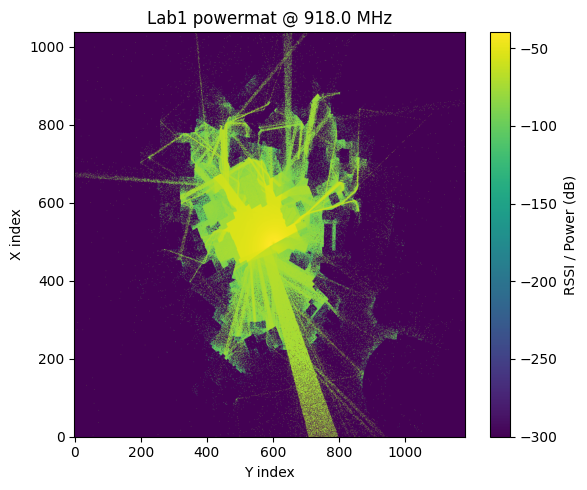

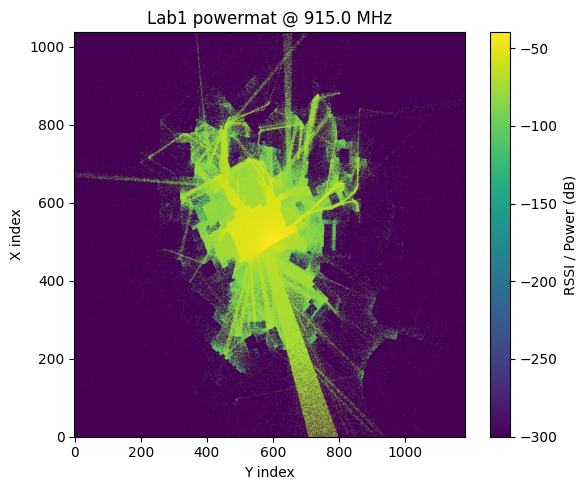

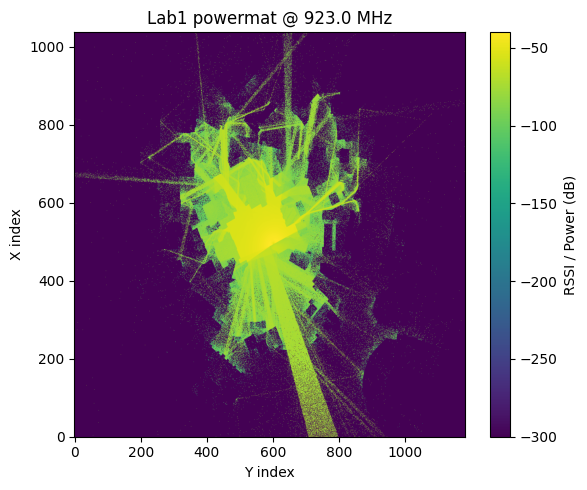

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

base_dir = GENERATED_DIR
save_dir = base_dir / "radio_map_lab1_27freq"

data = np.load(save_dir / "lab1_27freq_powermat.npz")

powermat = data["powermat"]   # [H, W, 27], dB
freqs = data["freqs"]         # [27]

# Select three frequencies for visualization.
rng = np.random.default_rng(0)  # Fixed seed for reproducibility.
freq_indices = rng.choice(len(freqs), size=3, replace=False)

for idx in freq_indices:
    plt.figure(figsize=(6, 5))
    plt.imshow(powermat[:, :, idx], origin="lower", aspect="auto")
    plt.colorbar(label="RSSI / Power (dB)")
    plt.title(f"Lab1 powermat @ {freqs[idx]/1e6:.1f} MHz")
    plt.xlabel("Y index")
    plt.ylabel("X index")
    plt.tight_layout()
    plt.show()

Using freq: 915.0 MHz
valid points: 77730


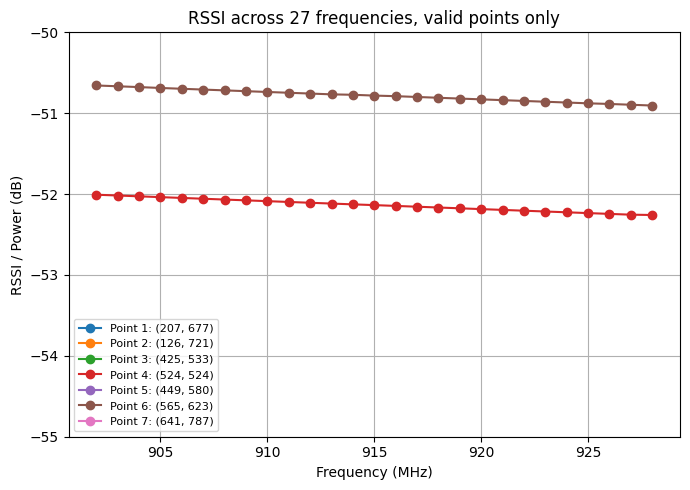

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

base_dir = GENERATED_DIR
save_dir = base_dir / "radio_map_lab1_27freq"

data = np.load(save_dir / "lab1_27freq_powermat.npz")
powermat = data["powermat"]   # [H, W, 27], dB
freqs = data["freqs"]         # Hz

# Find the frequency index nearest to 915 MHz.
target_freq = 915e6
idx_915 = np.argmin(np.abs(freqs - target_freq))
print("Using freq:", freqs[idx_915] / 1e6, "MHz")

# Retain points with RSSI >= -75 dB at 915 MHz.
valid_mask = powermat[:, :, idx_915] >= -75
valid_points = np.argwhere(valid_mask)   # shape [N_valid, 2]

print("valid points:", len(valid_points))

# Select seven valid points.
rng = np.random.default_rng(0)
chosen_idx = rng.choice(len(valid_points), size=7, replace=False)
chosen_points = valid_points[chosen_idx]

plt.figure(figsize=(7, 5))

for n, (x, y) in enumerate(chosen_points):
    rssi_curve = powermat[x, y, :]
    plt.plot(freqs / 1e6, rssi_curve, marker="o",
             label=f"Point {n+1}: ({x}, {y})")

plt.grid(True)
plt.xlabel("Frequency (MHz)")
plt.ylabel("RSSI / Power (dB)")
plt.ylim([-55, -50])
plt.title("RSSI across 27 frequencies, valid points only")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()